In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

In [3]:
# Read stellar parameters from Mamajek table
file_path = 'mamajek_stellar_masses.txt'

# Read the file and parse the data
stellar_types = []
masses = []
radii = []
luminosities = []
temperatures = []
bv_indices = []

# Define the stellar types we want (M through F main sequence)
target_types = ['M0V', 'M1V', 'M2V', 'M3V', 'M4V', 'M5V', 'M6V', 
                'K0V', 'K1V', 'K2V', 'K3V', 'K4V', 'K5V', 'K6V', 'K7V', 'K8V', 'K9V',
                'G0V', 'G1V', 'G2V', 'G3V', 'G4V', 'G5V', 'G6V', 'G7V', 'G8V', 'G9V',
                'F0V', 'F1V', 'F2V', 'F3V', 'F4V', 'F5V', 'F6V', 'F7V', 'F8V', 'F9V']

with open(file_path, 'r') as f:
    for line in f:
        # Skip comments and empty lines
        if line.startswith('#') or line.strip() == '':
            continue
        
        parts = line.split()
        if len(parts) < 8:
            continue
            
        # First column is spectral type
        spt = parts[0]
        
        # Only process types we're interested in
        if spt in target_types:
            try:
                teff = float(parts[1])      # Effective temperature
                logl = float(parts[4])      # log Luminosity
                radius = float(parts[6])    # Radius in solar radii
                bv = float(parts[8])        # B-V color index
                mass = float(parts[-2])     # Mass in solar masses (second to last column)
                
                stellar_types.append(spt)
                temperatures.append(teff)
                luminosities.append(10**logl)  # Convert from log to linear
                radii.append(radius)
                bv_indices.append(bv)
                masses.append(mass)
            except ValueError:
                # Skip lines with missing or invalid data
                continue

# Create DataFrame
data = {
    'Stellar Type': stellar_types,
    'Mass': masses,
    'Radius': radii,
    'Luminosity': luminosities,
    'Effective Temperature': temperatures,
    'B-V Index': bv_indices
}

data['4% Dust Mass'] = [mass * 0.04 for mass in data['Mass']]
data['1/R^2'] = [1 / (radius ** 2) for radius in data['Radius']]

stellar_df = pd.DataFrame(data)
stellar_df = stellar_df.sort_values(by='Effective Temperature', ascending=True)
print(stellar_df)

   Stellar Type   Mass  Radius  Luminosity  Effective Temperature  B-V Index  \
36          M6V  0.102   0.137    0.001047                 2810.0      2.010   
35          M5V  0.162   0.196    0.003020                 3060.0      1.830   
34          M4V  0.230   0.274    0.007244                 3210.0      1.650   
33          M3V  0.370   0.361    0.016218                 3430.0      1.530   
32          M2V  0.440   0.446    0.028840                 3560.0      1.505   
31          M1V  0.500   0.501    0.040738                 3660.0      1.485   
30          M0V  0.570   0.588    0.069183                 3850.0      1.420   
29          K9V  0.590   0.608    0.079433                 3930.0      1.400   
28          K8V  0.620   0.615    0.087096                 3990.0      1.363   
27          K7V  0.640   0.630    0.100000                 4100.0      1.340   
26          K6V  0.690   0.669    0.138038                 4300.0      1.240   
25          K5V  0.700   0.701    0.1737

Number of planets in 3000-3500 K bin: 40
Planet radii error in 3000-3500 K bin: 0.16
Median planet radius in 3000-3500 K bin: 2.54 R_Earth
Number of planets in 3500-4000 K bin: 84
Planet radii error in 3500-4000 K bin: 0.11
Median planet radius in 3500-4000 K bin: 2.43 R_Earth
Number of planets in 4000-4500 K bin: 99
Planet radii error in 4000-4500 K bin: 0.10
Median planet radius in 4000-4500 K bin: 2.76 R_Earth
Number of planets in 4500-5000 K bin: 117
Planet radii error in 4500-5000 K bin: 0.09
Median planet radius in 4500-5000 K bin: 2.80 R_Earth
Number of planets in 5000-5500 K bin: 196
Planet radii error in 5000-5500 K bin: 0.07
Median planet radius in 5000-5500 K bin: 2.74 R_Earth
Number of planets in 5500-6000 K bin: 253
Planet radii error in 5500-6000 K bin: 0.06
Median planet radius in 5500-6000 K bin: 2.75 R_Earth
Number of planets in 6000-6500 K bin: 156
Planet radii error in 6000-6500 K bin: 0.08
Median planet radius in 6000-6500 K bin: 2.76 R_Earth
Number of planets in 65

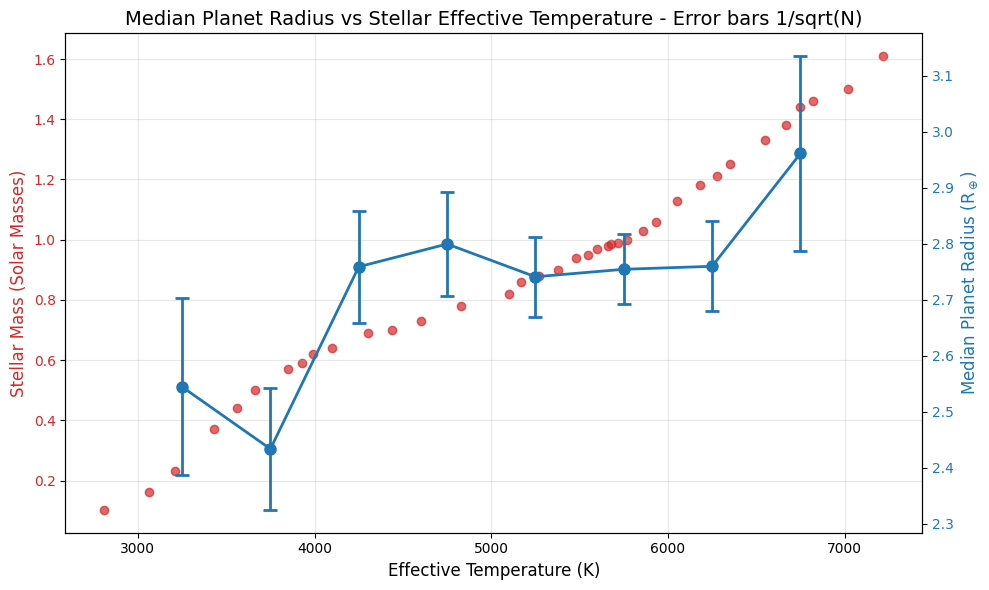

In [16]:
TOIs = pd.read_csv("TOI_Mar2025_1pt5to4_R_with_extra_columns.csv")
bins_teff = [3000, 3500, 4000, 4500, 5000, 5500, 6000, 6500, 7000]

# Remove false alarms and select planets with radius > 2 R_Earth
TOIs = TOIs[TOIs['tfopwg_disp'] != 'FA']
TOIs = TOIs[TOIs['pl_rade'] > 2]
# Calculate errors for each bin
planet_radii_errors = []
planet_radii_medians = []
bin_centers = []

for i in range(len(bins_teff)-1):
    bin_mask = (TOIs['st_teff'] >= bins_teff[i]) & (TOIs['st_teff'] < bins_teff[i+1])
    planet_radii = TOIs.loc[bin_mask, 'pl_rade']
    planet_radii_n = len(planet_radii)
    planet_radii_error = 1/np.sqrt(planet_radii_n)
    print(f"Number of planets in {bins_teff[i]}-{bins_teff[i+1]} K bin: {planet_radii_n}")
    print(f"Planet radii error in {bins_teff[i]}-{bins_teff[i+1]} K bin: {planet_radii_error:.2f}")

    planet_radii_median = np.median(planet_radii)
    print(f"Median planet radius in {bins_teff[i]}-{bins_teff[i+1]} K bin: {planet_radii_median:.2f} R_Earth")
    
    planet_radii_medians.append(planet_radii_median)
    planet_radii_errors.append(planet_radii_error)
    bin_centers.append((bins_teff[i] + bins_teff[i+1]) / 2)

print(len(planet_radii_medians), len(planet_radii_errors), len(bin_centers))

# Plot stellar mass on primary y-axis
fig, ax1 = plt.subplots(figsize=(10, 6))
ax1.scatter(stellar_df['Effective Temperature'], stellar_df['Mass'], color='tab:red', label='Stellar Mass', alpha=0.7)
ax1.set_xlabel('Effective Temperature (K)', fontsize=12)
ax1.set_ylabel('Stellar Mass (Solar Masses)', fontsize=12, color='tab:red')
ax1.tick_params(axis='y', labelcolor='tab:red')
ax1.set_title('Median Planet Radius vs Stellar Effective Temperature - Error bars 1/sqrt(N)', fontsize=14)
ax1.grid(True, alpha=0.3)

# Create secondary y-axis for median planet radius with error bars
ax2 = ax1.twinx()
ax2.errorbar(bin_centers, planet_radii_medians, yerr=planet_radii_errors, 
             marker='o', linewidth=2, markersize=8, capsize=5, capthick=2, color='tab:blue')
ax2.set_ylabel('Median Planet Radius (R$_\oplus$)', fontsize=12, color='tab:blue')
ax2.tick_params(axis='y', labelcolor='tab:blue')

plt.tight_layout()
plt.show()


Number of planets in 3000-3500 K bin: 40
Planet radii error in 3000-3500 K bin: 0.50
Median planet radius in 3000-3500 K bin: 2.54 R_Earth
Number of planets in 3500-4000 K bin: 84
Planet radii error in 3500-4000 K bin: 0.52
Median planet radius in 3500-4000 K bin: 2.43 R_Earth
Number of planets in 4000-4500 K bin: 99
Planet radii error in 4000-4500 K bin: 0.48
Median planet radius in 4000-4500 K bin: 2.76 R_Earth
Number of planets in 4500-5000 K bin: 117
Planet radii error in 4500-5000 K bin: 0.52
Median planet radius in 4500-5000 K bin: 2.80 R_Earth
Number of planets in 5000-5500 K bin: 196
Planet radii error in 5000-5500 K bin: 0.55
Median planet radius in 5000-5500 K bin: 2.74 R_Earth
Number of planets in 5500-6000 K bin: 253
Planet radii error in 5500-6000 K bin: 0.52
Median planet radius in 5500-6000 K bin: 2.75 R_Earth
Number of planets in 6000-6500 K bin: 156
Planet radii error in 6000-6500 K bin: 0.54
Median planet radius in 6000-6500 K bin: 2.76 R_Earth
Number of planets in 65

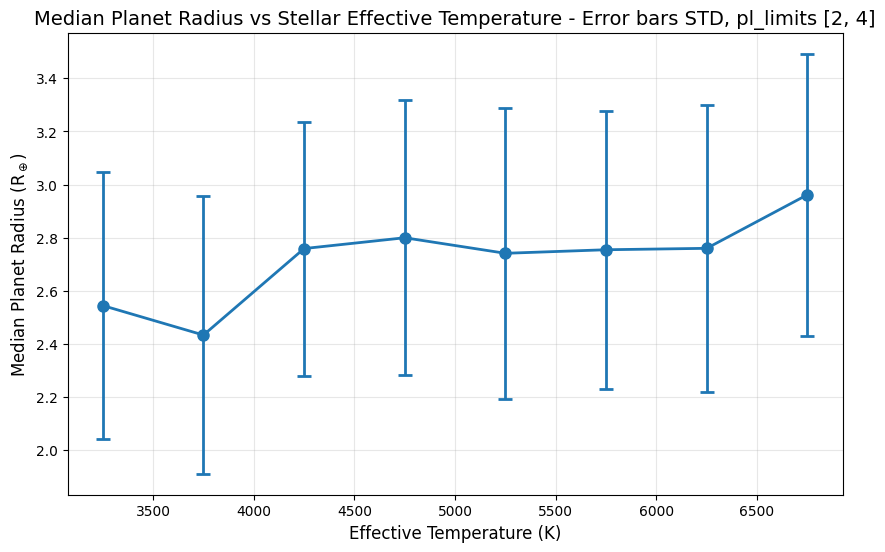

In [40]:
TOIs = pd.read_csv("TOI_Mar2025_1pt5to4_R_with_extra_columns.csv")
TOIs = pd.read_csv("TOI_Mar2025_0to6_R.csv")
bins_teff = [3000, 3500, 4000, 4500, 5000, 5500, 6000, 6500, 7000]

TOIs = TOIs[TOIs['tfopwg_disp'] != 'FA']

pl_limits = [2,4]
TOIs = TOIs[TOIs['pl_rade'] > pl_limits[0]]
TOIs = TOIs[TOIs['pl_rade'] < pl_limits[1]]


# Calculate errors for each bin
planet_radii_errors = []
planet_radii_medians = []
bin_centers = []

for i in range(len(bins_teff)-1):
    bin_mask = (TOIs['st_teff'] >= bins_teff[i]) & (TOIs['st_teff'] < bins_teff[i+1])
    planet_radii = TOIs.loc[bin_mask, 'pl_rade']
    planet_radii_n = len(planet_radii)
    planet_radii_error = np.std(planet_radii)
    print(f"Number of planets in {bins_teff[i]}-{bins_teff[i+1]} K bin: {planet_radii_n}")
    print(f"Planet radii error in {bins_teff[i]}-{bins_teff[i+1]} K bin: {planet_radii_error:.2f}")

    planet_radii_median = np.median(planet_radii)
    print(f"Median planet radius in {bins_teff[i]}-{bins_teff[i+1]} K bin: {planet_radii_median:.2f} R_Earth")
    
    planet_radii_medians.append(planet_radii_median)
    planet_radii_errors.append(planet_radii_error)
    bin_centers.append((bins_teff[i] + bins_teff[i+1]) / 2)

print(len(planet_radii_medians), len(planet_radii_errors), len(bin_centers))

# Plot the medians with error bars
plt.figure(figsize=(10, 6))
plt.errorbar(bin_centers, planet_radii_medians, yerr=planet_radii_errors, 
             marker='o', linewidth=2, markersize=8, capsize=5, capthick=2)
plt.xlabel('Effective Temperature (K)', fontsize=12)
plt.ylabel('Median Planet Radius (R$_\oplus$)', fontsize=12)
plt.title(f'Median Planet Radius vs Stellar Effective Temperature - Error bars STD, pl_limits {pl_limits}', fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()

Number of planets in 3000-3500 K bin: 68
Planet radii error in 3000-3500 K bin: 0.56
Median planet radius in 3000-3500 K bin: 2.06 R_Earth
Number of planets in 3500-4000 K bin: 119
Planet radii error in 3500-4000 K bin: 0.58
Median planet radius in 3500-4000 K bin: 2.25 R_Earth
Number of planets in 4000-4500 K bin: 121
Planet radii error in 4000-4500 K bin: 0.59
Median planet radius in 4000-4500 K bin: 2.59 R_Earth
Number of planets in 4500-5000 K bin: 147
Planet radii error in 4500-5000 K bin: 0.65
Median planet radius in 4500-5000 K bin: 2.61 R_Earth
Number of planets in 5000-5500 K bin: 226
Planet radii error in 5000-5500 K bin: 0.63
Median planet radius in 5000-5500 K bin: 2.65 R_Earth
Number of planets in 5500-6000 K bin: 297
Planet radii error in 5500-6000 K bin: 0.63
Median planet radius in 5500-6000 K bin: 2.63 R_Earth
Number of planets in 6000-6500 K bin: 171
Planet radii error in 6000-6500 K bin: 0.60
Median planet radius in 6000-6500 K bin: 2.68 R_Earth
Number of planets in 

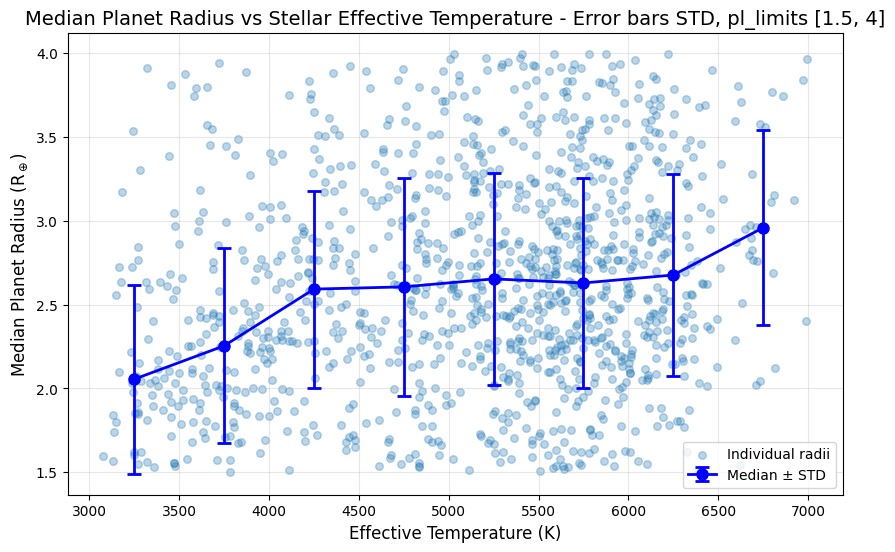

In [41]:
TOIs = pd.read_csv("TOI_Mar2025_0to6_R.csv")
bins_teff = [3000, 3500, 4000, 4500, 5000, 5500, 6000, 6500, 7000]

TOIs = TOIs[TOIs['tfopwg_disp'] != 'FA']

pl_limits = [1.5,4]
TOIs = TOIs[TOIs['pl_rade'] > pl_limits[0]]
TOIs = TOIs[TOIs['pl_rade'] < pl_limits[1]]

# Calculate errors for each bin
planet_radii_errors = []
planet_radii_medians = []
bin_centers = []

plt.figure(figsize=(10, 6))

for i in range(len(bins_teff)-1):
    bin_mask = (TOIs['st_teff'] >= bins_teff[i]) & (TOIs['st_teff'] < bins_teff[i+1])
    planet_radii = TOIs.loc[bin_mask, 'pl_rade']
    planet_teff = TOIs.loc[bin_mask, 'st_teff']
    planet_radii_n = len(planet_radii)
    planet_radii_error = np.std(planet_radii)
    print(f"Number of planets in {bins_teff[i]}-{bins_teff[i+1]} K bin: {planet_radii_n}")
    print(f"Planet radii error in {bins_teff[i]}-{bins_teff[i+1]} K bin: {planet_radii_error:.2f}")

    planet_radii_median = np.median(planet_radii)
    print(f"Median planet radius in {bins_teff[i]}-{bins_teff[i+1]} K bin: {planet_radii_median:.2f} R_Earth")
    
    planet_radii_medians.append(planet_radii_median)
    planet_radii_errors.append(planet_radii_error)
    bin_centers.append((bins_teff[i] + bins_teff[i+1]) / 2)

    # Overlay individual radii as semi-transparent dots for this bin, using true temperature
    if len(planet_radii) > 0:
        plt.scatter(planet_teff, planet_radii, color='C0', alpha=0.3, s=30, label='Individual radii' if i == 0 else "")

print(len(planet_radii_medians), len(planet_radii_errors), len(bin_centers))

# Plot the medians with error bars
plt.errorbar(bin_centers, planet_radii_medians, yerr=planet_radii_errors, 
             marker='o', linewidth=2, markersize=8, capsize=5, capthick=2, color='blue', label='Median ± STD')
plt.xlabel('Effective Temperature (K)', fontsize=12)
plt.ylabel('Median Planet Radius (R$_\oplus$)', fontsize=12)
plt.title(f'Median Planet Radius vs Stellar Effective Temperature - Error bars STD, pl_limits {pl_limits}', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()

plt.show()


Number of planets in 3000-3500 K bin: 70
Planet radii error in 3000-3500 K bin: 0.06
Median planet radius in 3000-3500 K bin: 2.06 R_Earth
Number of planets in 3500-4000 K bin: 121
Planet radii error in 3500-4000 K bin: 0.05
Median planet radius in 3500-4000 K bin: 2.27 R_Earth
Number of planets in 4000-4500 K bin: 122
Planet radii error in 4000-4500 K bin: 0.08
Median planet radius in 4000-4500 K bin: 2.59 R_Earth
Number of planets in 4500-5000 K bin: 149
Planet radii error in 4500-5000 K bin: 0.08
Median planet radius in 4500-5000 K bin: 2.61 R_Earth
Number of planets in 5000-5500 K bin: 232
Planet radii error in 5000-5500 K bin: 0.05
Median planet radius in 5000-5500 K bin: 2.64 R_Earth
Number of planets in 5500-6000 K bin: 309
Planet radii error in 5500-6000 K bin: 0.05
Median planet radius in 5500-6000 K bin: 2.63 R_Earth
Number of planets in 6000-6500 K bin: 183
Planet radii error in 6000-6500 K bin: 0.08
Median planet radius in 6000-6500 K bin: 2.69 R_Earth
Number of planets in 

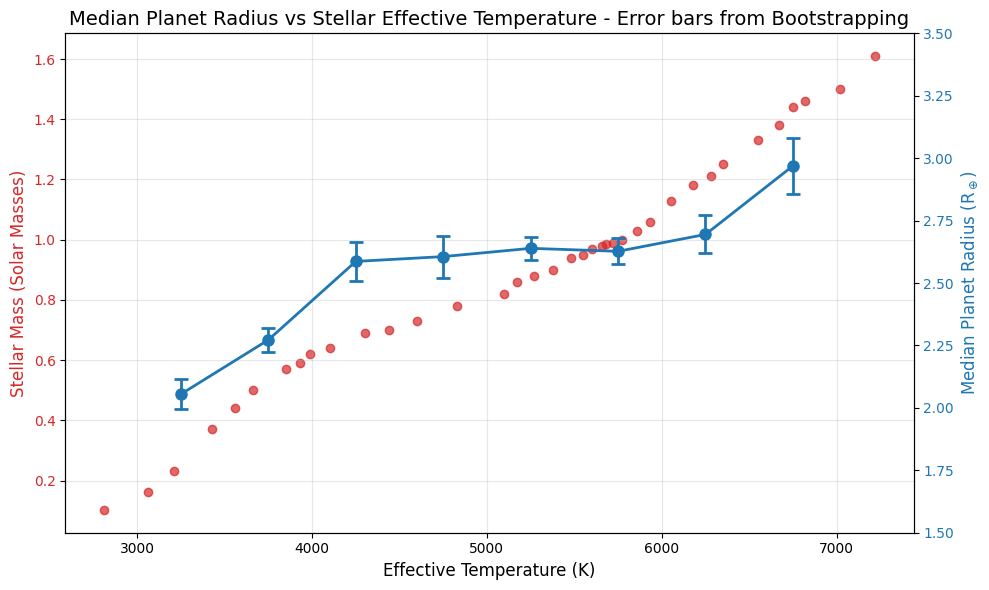

In [ ]:
TOIs = pd.read_csv("TOI_Mar2025_1pt5to4_R_with_extra_columns.csv")
bins_teff = [3000, 3500, 4000, 4500, 5000, 5500, 6000, 6500, 7000]

# Calculate errors for each bin using bootstrapping
planet_radii_errors = []
planet_radii_medians = []
bin_centers = []

n_bootstrap = 1000

for i in range(len(bins_teff)-1):
    bin_mask = (TOIs['st_teff'] >= bins_teff[i]) & (TOIs['st_teff'] < bins_teff[i+1])
    planet_radii = TOIs.loc[bin_mask, 'pl_rade']
    planet_radii_n = len(planet_radii)
    
    # Bootstrap resampling
    bootstrap_medians = []
    for _ in range(n_bootstrap):
        bootstrap_sample = planet_radii.sample(n=planet_radii_n, replace=True)
        bootstrap_medians.append(np.median(bootstrap_sample))
    
    planet_radii_error = np.std(bootstrap_medians)
    print(f"Number of planets in {bins_teff[i]}-{bins_teff[i+1]} K bin: {planet_radii_n}")
    print(f"Planet radii error in {bins_teff[i]}-{bins_teff[i+1]} K bin: {planet_radii_error:.2f}")

    planet_radii_median = np.median(planet_radii)
    print(f"Median planet radius in {bins_teff[i]}-{bins_teff[i+1]} K bin: {planet_radii_median:.2f} R_Earth")
    
    planet_radii_medians.append(planet_radii_median)
    planet_radii_errors.append(planet_radii_error)
    bin_centers.append((bins_teff[i] + bins_teff[i+1]) / 2)

print(len(planet_radii_medians), len(planet_radii_errors), len(bin_centers))

# Plot stellar mass on primary y-axis
fig, ax1 = plt.subplots(figsize=(10, 6))
ax1.scatter(stellar_df['Effective Temperature'], stellar_df['Mass'], color='tab:red', label='Stellar Mass', alpha=0.7)
ax1.set_xlabel('Effective Temperature (K)', fontsize=12)
ax1.set_ylabel('Stellar Mass (Solar Masses)', fontsize=12, color='tab:red')
ax1.tick_params(axis='y', labelcolor='tab:red')
ax1.set_title('Median Planet Radius vs Stellar Effective Temperature - Error bars from Bootstrapping', fontsize=14)
ax1.grid(True, alpha=0.3)

# Create secondary y-axis for median planet radius with error bars
ax2 = ax1.twinx()
ax2.errorbar(bin_centers, planet_radii_medians, yerr=planet_radii_errors, 
             marker='o', linewidth=2, markersize=8, capsize=5, capthick=2, color='tab:blue')
ax2.set_ylabel('Median Planet Radius (R$_\oplus$)', fontsize=12, color='tab:blue')
ax2.tick_params(axis='y', labelcolor='tab:blue')
ax2.set_ylim(1.5,3.5)

plt.tight_layout()
plt.show()
